In [ ]:
from google.colab import files
files.upload()

In [ ]:
import zipfile

with zipfile.ZipFile("data_taling.zip",'r') as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
import os
os.listdir("/content/data_taling")

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data_taling",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=16
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data_taling",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=16
)

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y: (normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y: (normalization_layer(x),y))

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dense(4,activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 483ms/step - accuracy: 0.8871 - loss: 0.4262 - val_accuracy: 0.9348 - val_loss: 0.2616
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 646ms/step - accuracy: 0.8763 - loss: 0.3049 - val_accuracy: 0.8913 - val_loss: 0.2421
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 478ms/step - accuracy: 0.9731 - loss: 0.1587 - val_accuracy: 0.9130 - val_loss: 0.1347
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 606ms/step - accuracy: 0.9946 - loss: 0.0344 - val_accuracy: 0.9565 - val_loss: 0.0869
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 491ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 0.9565 - val_loss: 0.1011


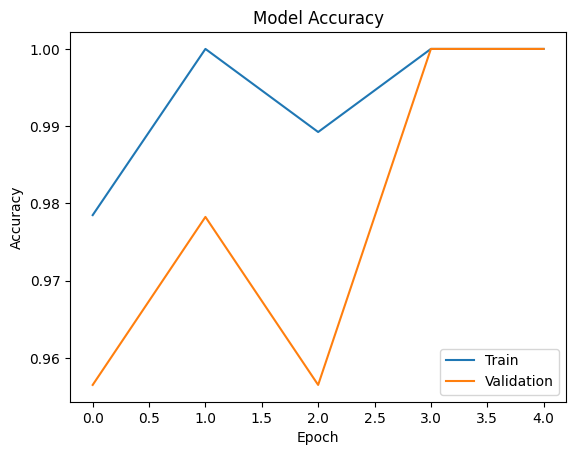

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-03-16 230705.png to Screenshot 2026-03-16 230705.png


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

classes = ["blue","green","purple","red"]

print("Prediction:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: purple


Prediction: purple


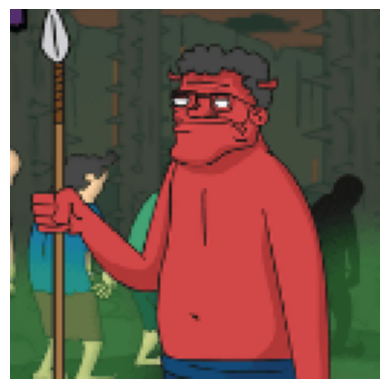

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")

print("Prediction:", classes[np.argmax(prediction)])

In [ ]:
model.save('my_model.keras')

In [ ]:
from google.colab import files
files.download("my_model.keras")

FileNotFoundError: Cannot find file: my_model.keras

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0
